<a href="https://www.kaggle.com/code/sonawanelalitsunil/disney-princess-popularity-ml-56-67?scriptVersionId=236478348" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/disney-princess-popularity-dataset/disney_princess_popularity_dataset_300_rows.csv


## Title: Disney Princess Popularity

#### Description:
Explore the popularity trends of Disney Princesses based on various metrics like fan ratings, movie releases, and social media mentions.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/disney-princess-popularity-dataset/disney_princess_popularity_dataset_300_rows.csv')

In [3]:
df.head()

,PrincessName,FirstMovieTitle,FirstMovieYear,MovieRuntimeMinutes,NumberOfSongs,HasSoloSong,HasDuet,HairColor,EyeColor,OutfitPrimaryColor,...,RottenTomatoesScore,BoxOfficeMillions,AvgScreenTimeMinutes,NumMerchItemsOnAmazon,GoogleSearchIndex2024,InstagramFanPages,TikTokHashtagViewsMillions,Top3Hashtags,IsIconic,PopularityScore
0,Pocahontas,Pocahontas's Adventure,1977,85,4,No,Yes,Brown,Green,Pink,...,88,661,25,2524,68,298,481,#TeamPocahontas #LovePocahontas #PocahontasFor...,Yes,88
1,Mulan,Mulan's Adventure,1995,85,1,Yes,Yes,Blonde,Brown,Purple,...,91,688,52,4202,49,133,619,#TeamMulan #LoveMulan #MulanForever,Yes,78
2,Raya,Raya's Adventure,1989,110,4,No,No,Blonde,Hazel,Pink,...,76,790,54,525,68,129,230,#TeamRaya #LoveRaya #RayaForever,No,53
3,Anna,Anna's Adventure,1940,78,1,No,No,Brown,Grey,Green,...,70,820,42,1951,73,138,697,#TeamAnna #LoveAnna #AnnaForever,Yes,84
4,Mulan,Mulan's Adventure,1943,103,7,No,Yes,White,Brown,Green,...,86,996,55,3958,34,155,200,#TeamMulan #LoveMulan #MulanForever,Yes,71


In [4]:
df.tail()

,PrincessName,FirstMovieTitle,FirstMovieYear,MovieRuntimeMinutes,NumberOfSongs,HasSoloSong,HasDuet,HairColor,EyeColor,OutfitPrimaryColor,...,RottenTomatoesScore,BoxOfficeMillions,AvgScreenTimeMinutes,NumMerchItemsOnAmazon,GoogleSearchIndex2024,InstagramFanPages,TikTokHashtagViewsMillions,Top3Hashtags,IsIconic,PopularityScore
295,Merida,Merida's Adventure,2001,95,7,Yes,No,Red,Grey,Purple,...,89,309,49,3638,98,225,881,#TeamMerida #LoveMerida #MeridaForever,No,95
296,Belle,Belle's Adventure,2006,76,1,Yes,No,Red,Green,Yellow,...,97,406,53,1558,33,270,274,#TeamBelle #LoveBelle #BelleForever,No,96
297,Anna,Anna's Adventure,2020,70,2,No,Yes,White,Blue,Blue,...,72,935,25,1815,53,53,164,#TeamAnna #LoveAnna #AnnaForever,Yes,67
298,Tiana,Tiana's Adventure,1937,71,7,No,No,Red,Blue,Purple,...,86,463,54,2365,35,116,584,#TeamTiana #LoveTiana #TianaForever,No,76
299,Mulan,Mulan's Adventure,1938,105,3,No,No,Brown,Brown,Purple,...,77,195,42,2218,89,11,540,#TeamMulan #LoveMulan #MulanForever,No,69


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PrincessName                300 non-null    object 
 1   FirstMovieTitle             300 non-null    object 
 2   FirstMovieYear              300 non-null    int64  
 3   MovieRuntimeMinutes         300 non-null    int64  
 4   NumberOfSongs               300 non-null    int64  
 5   HasSoloSong                 300 non-null    object 
 6   HasDuet                     300 non-null    object 
 7   HairColor                   300 non-null    object 
 8   EyeColor                    300 non-null    object 
 9   OutfitPrimaryColor          300 non-null    object 
 10  OutfitStyleEra              300 non-null    object 
 11  IsRoyalByBirth              300 non-null    object 
 12  HasAnimalSidekick           300 non-null    object 
 13  SidekickType                230 non

In [6]:
df.describe()

,FirstMovieYear,MovieRuntimeMinutes,NumberOfSongs,IMDB_Rating,RottenTomatoesScore,BoxOfficeMillions,AvgScreenTimeMinutes,NumMerchItemsOnAmazon,GoogleSearchIndex2024,InstagramFanPages,TikTokHashtagViewsMillions,PopularityScore
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1980.243333,90.913333,3.993333,7.466667,80.650000,700.843333,40.616667,2467.270000,61.300000,152.063333,506.870000,75.130000
std,24.621227,11.726502,2.149890,0.863311,10.996237,346.922618,11.575680,1469.301225,22.393785,83.929214,292.751278,14.293382
min,1937.000000,70.000000,1.000000,6.000000,60.000000,101.000000,20.000000,61.000000,20.000000,10.000000,10.000000,50.000000
25%,1959.750000,80.000000,2.000000,6.700000,71.750000,392.000000,31.750000,1223.500000,41.750000,75.750000,236.500000,63.000000
50%,1983.000000,91.000000,4.000000,7.400000,80.000000,709.500000,41.000000,2357.500000,61.000000,148.500000,524.500000,75.000000
75%,2000.250000,101.000000,6.000000,8.200000,90.000000,997.250000,51.000000,3743.250000,81.000000,227.250000,781.250000,87.000000
max,2021.000000,110.000000,7.000000,9.000000,100.000000,1300.000000,60.000000,4998.000000,100.000000,300.000000,999.000000,100.000000


In [7]:
df.isnull().sum()

PrincessName                   0
FirstMovieTitle                0
FirstMovieYear                 0
MovieRuntimeMinutes            0
NumberOfSongs                  0
HasSoloSong                    0
HasDuet                        0
HairColor                      0
EyeColor                       0
OutfitPrimaryColor             0
OutfitStyleEra                 0
IsRoyalByBirth                 0
HasAnimalSidekick              0
SidekickType                  70
HasMagicalPowers               0
MagicType                     53
MainSetting                    0
IsBasedOnRealStory             0
CulturalOrigin                 0
SpeaksToAnimals                0
FightsVillainDirectly          0
RomanticSubplot                0
MarriedByEnd                   0
VillainName                    0
VillainType                   47
IMDB_Rating                    0
RottenTomatoesScore            0
BoxOfficeMillions              0
AvgScreenTimeMinutes           0
NumMerchItemsOnAmazon          0
GoogleSear

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(300, 36)

In [10]:
df.dtypes

PrincessName                   object
FirstMovieTitle                object
FirstMovieYear                  int64
MovieRuntimeMinutes             int64
NumberOfSongs                   int64
HasSoloSong                    object
HasDuet                        object
HairColor                      object
EyeColor                       object
OutfitPrimaryColor             object
OutfitStyleEra                 object
IsRoyalByBirth                 object
HasAnimalSidekick              object
SidekickType                   object
HasMagicalPowers               object
MagicType                      object
MainSetting                    object
IsBasedOnRealStory             object
CulturalOrigin                 object
SpeaksToAnimals                object
FightsVillainDirectly          object
RomanticSubplot                object
MarriedByEnd                   object
VillainName                    object
VillainType                    object
IMDB_Rating                   float64
RottenTomato

In [11]:
df.columns

Index(['PrincessName', 'FirstMovieTitle', 'FirstMovieYear',
       'MovieRuntimeMinutes', 'NumberOfSongs', 'HasSoloSong', 'HasDuet',
       'HairColor', 'EyeColor', 'OutfitPrimaryColor', 'OutfitStyleEra',
       'IsRoyalByBirth', 'HasAnimalSidekick', 'SidekickType',
       'HasMagicalPowers', 'MagicType', 'MainSetting', 'IsBasedOnRealStory',
       'CulturalOrigin', 'SpeaksToAnimals', 'FightsVillainDirectly',
       'RomanticSubplot', 'MarriedByEnd', 'VillainName', 'VillainType',
       'IMDB_Rating', 'RottenTomatoesScore', 'BoxOfficeMillions',
       'AvgScreenTimeMinutes', 'NumMerchItemsOnAmazon',
       'GoogleSearchIndex2024', 'InstagramFanPages',
       'TikTokHashtagViewsMillions', 'Top3Hashtags', 'IsIconic',
       'PopularityScore'],
      dtype='object')

## Data visualizations

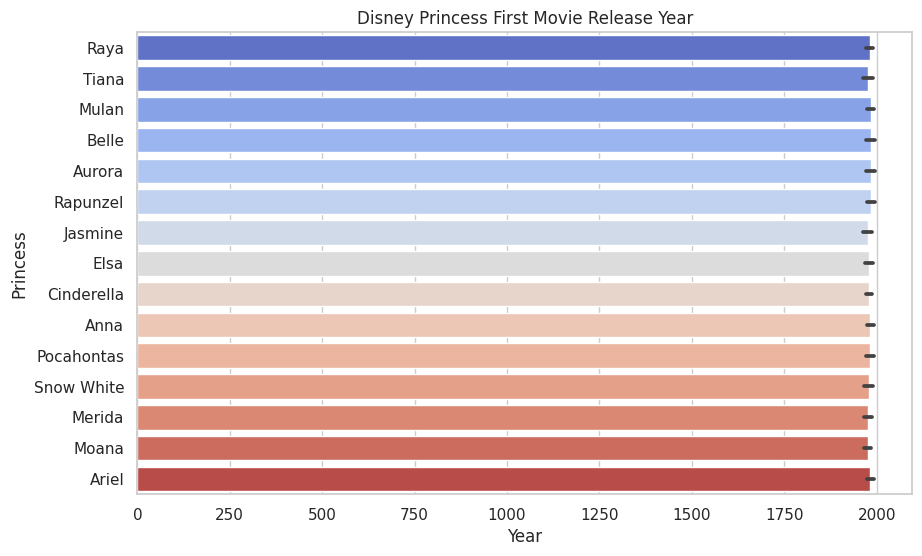

In [12]:
# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Movie Release Timeline
df_sorted = df.sort_values('FirstMovieYear')
plt.figure()
sns.barplot(x='FirstMovieYear', y='PrincessName', data=df_sorted, palette='coolwarm')
plt.title('Disney Princess First Movie Release Year')
plt.xlabel('Year')
plt.ylabel('Princess')
plt.show()

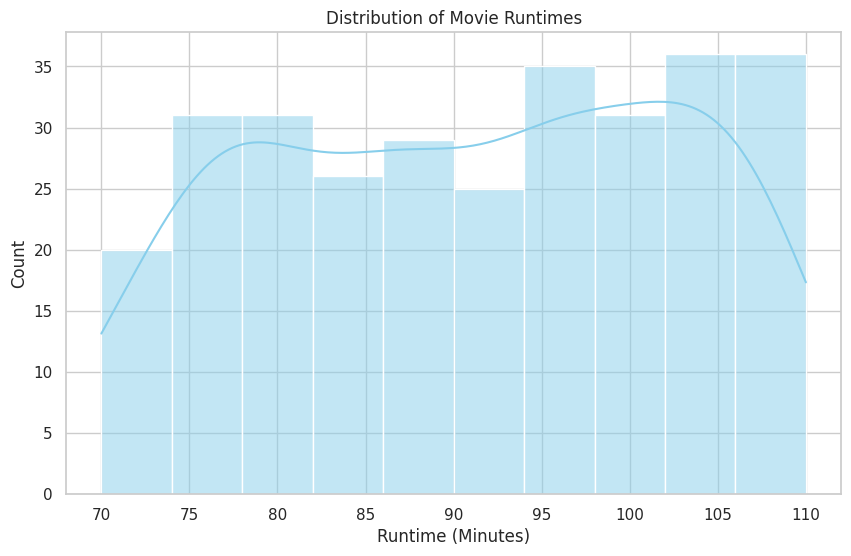

In [13]:
# 2. Movie Runtimes
plt.figure()
sns.histplot(df['MovieRuntimeMinutes'], kde=True, color='skyblue')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (Minutes)')
plt.show()

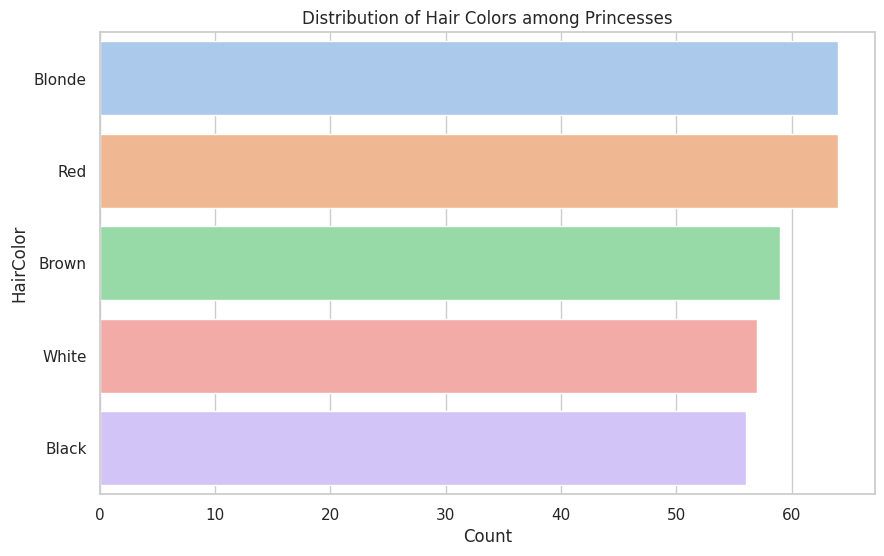

In [14]:
# 4. Hair Color
plt.figure()
sns.countplot(y='HairColor', data=df, order=df['HairColor'].value_counts().index, palette='pastel')
plt.title('Distribution of Hair Colors among Princesses')
plt.xlabel('Count')
plt.show()

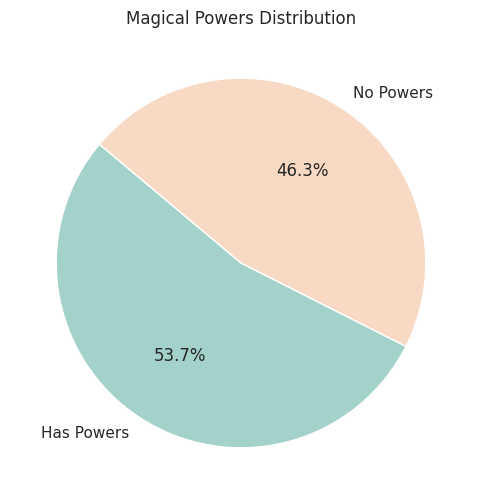

In [15]:
# 5. Magical Powers
plt.figure()
magic_counts = df['HasMagicalPowers'].value_counts()
magic_counts.plot(kind='pie', labels=['Has Powers', 'No Powers'], autopct='%1.1f%%', startangle=140, colors=['#a3d2ca', '#f7d9c4'])
plt.title('Magical Powers Distribution')
plt.ylabel('')
plt.show()

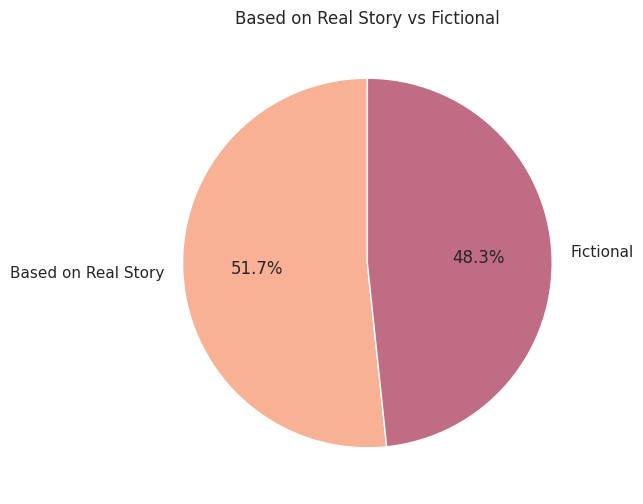

In [16]:
# 6. Based on Real Story
plt.figure()
real_story_counts = df['IsBasedOnRealStory'].value_counts()
real_story_counts.plot(kind='pie', labels=['Based on Real Story', 'Fictional'], autopct='%1.1f%%', startangle=90, colors=['#f8b195', '#c06c84'])
plt.title('Based on Real Story vs Fictional')
plt.ylabel('')
plt.show()

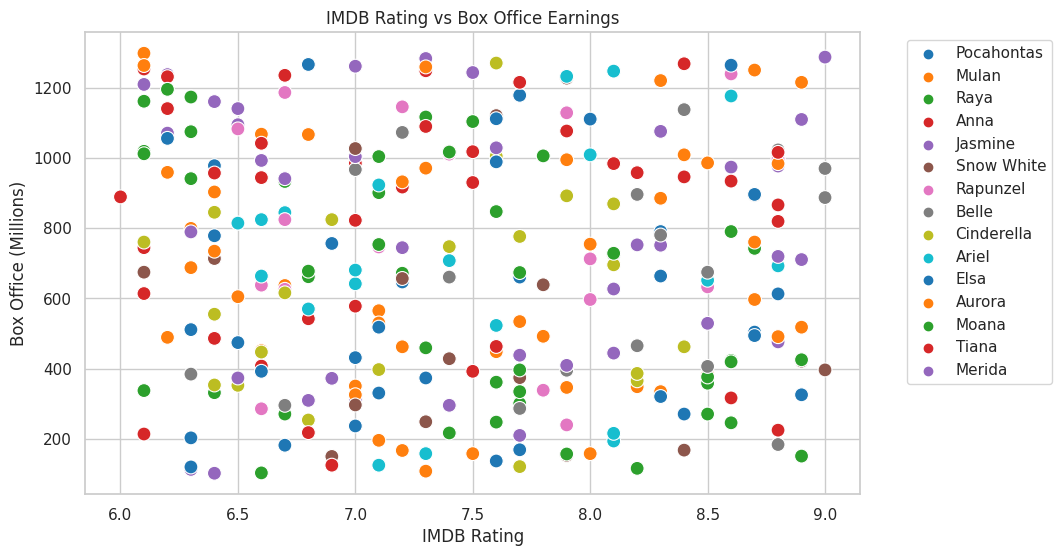

In [17]:
# 7. IMDB Ratings vs Box Office
plt.figure()
sns.scatterplot(x='IMDB_Rating', y='BoxOfficeMillions', hue='PrincessName', data=df, palette='tab10', s=100)
plt.title('IMDB Rating vs Box Office Earnings')
plt.xlabel('IMDB Rating')
plt.ylabel('Box Office (Millions)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

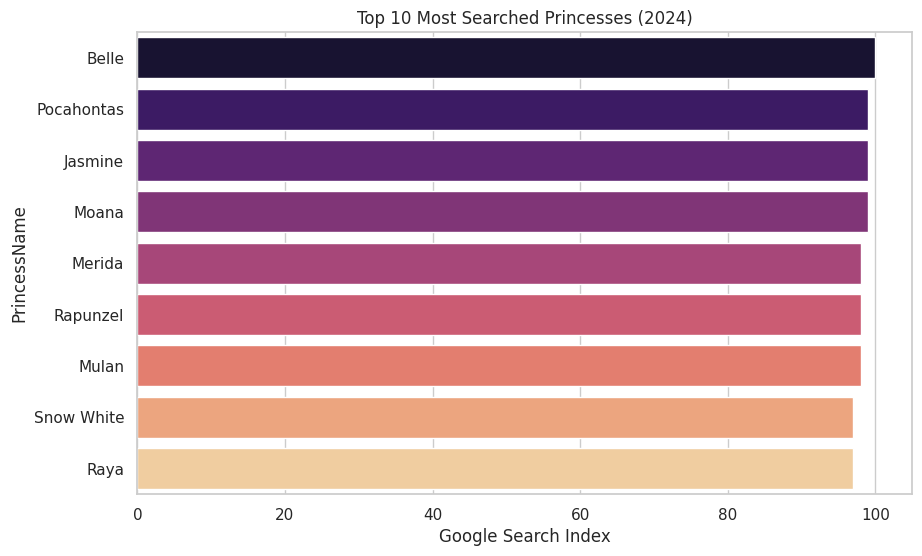

In [18]:
# 8. Google Search Popularity
top_searches = df.sort_values('GoogleSearchIndex2024', ascending=False).head(10)
plt.figure()
sns.barplot(x='GoogleSearchIndex2024', y='PrincessName', data=top_searches, palette='magma')
plt.title('Top 10 Most Searched Princesses (2024)')
plt.xlabel('Google Search Index')
plt.show()

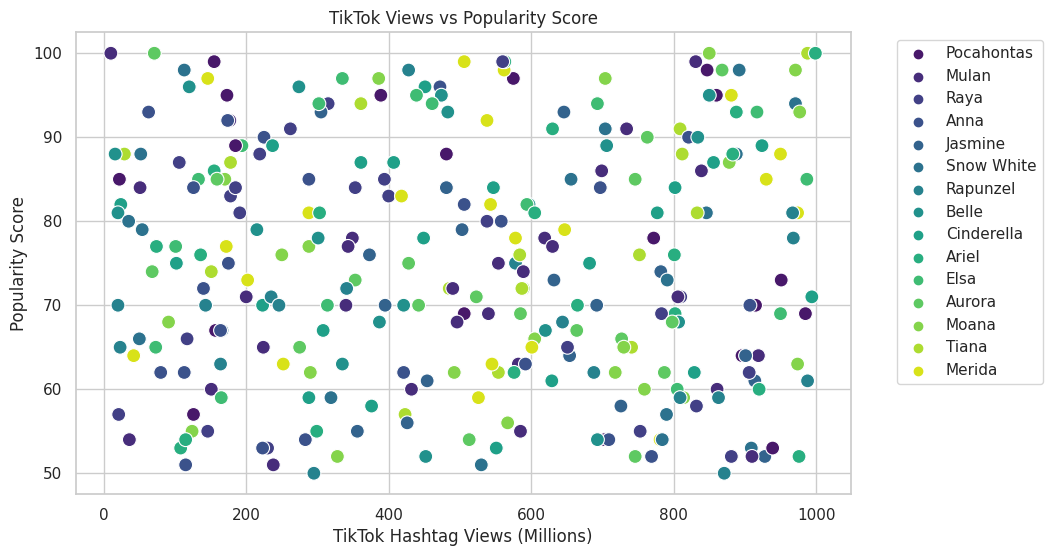

In [19]:
# 9. TikTok Hashtag Views
plt.figure()
sns.scatterplot(x='TikTokHashtagViewsMillions', y='PopularityScore', data=df, hue='PrincessName', palette='viridis', s=100)
plt.title('TikTok Views vs Popularity Score')
plt.xlabel('TikTok Hashtag Views (Millions)')
plt.ylabel('Popularity Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

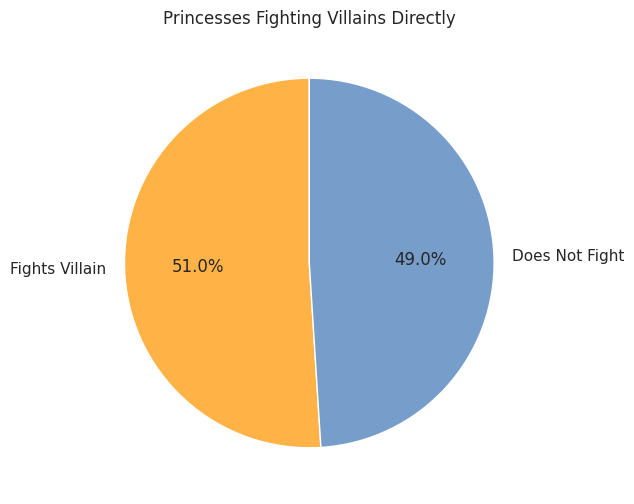

In [20]:
# 10. Fighting Villains
plt.figure()
villain_fight_counts = df['FightsVillainDirectly'].value_counts()
villain_fight_counts.plot(kind='pie', labels=['Fights Villain', 'Does Not Fight'], autopct='%1.1f%%', startangle=90, colors=['#ffb347','#779ecb'])
plt.title('Princesses Fighting Villains Directly')
plt.ylabel('')
plt.show()

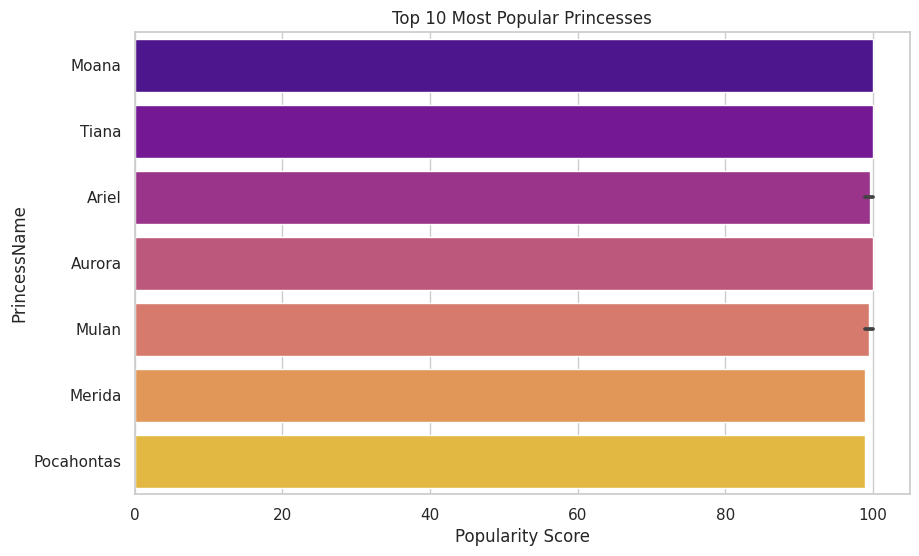

In [21]:
# 11. Top 10 Popularity Scores
top_popularity = df.sort_values('PopularityScore', ascending=False).head(10)
plt.figure()
sns.barplot(x='PopularityScore', y='PrincessName', data=top_popularity, palette='plasma')
plt.title('Top 10 Most Popular Princesses')
plt.xlabel('Popularity Score')
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [23]:
# Drop columns that are not useful for ML (example: Names, Movie Titles)
drop_cols = ['PrincessName', 'FirstMovieTitle', 'VillainName', 'Top3Hashtags']
df = df.drop(columns=drop_cols)

# Fill missing values (if any)
df = df.fillna('Unknown')

# Label Encoding all categorical columns
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Define X and y
X = df.drop('IsIconic', axis=1)  # We will predict 'IsIconic' (binary label)
y = df['IsIconic']

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


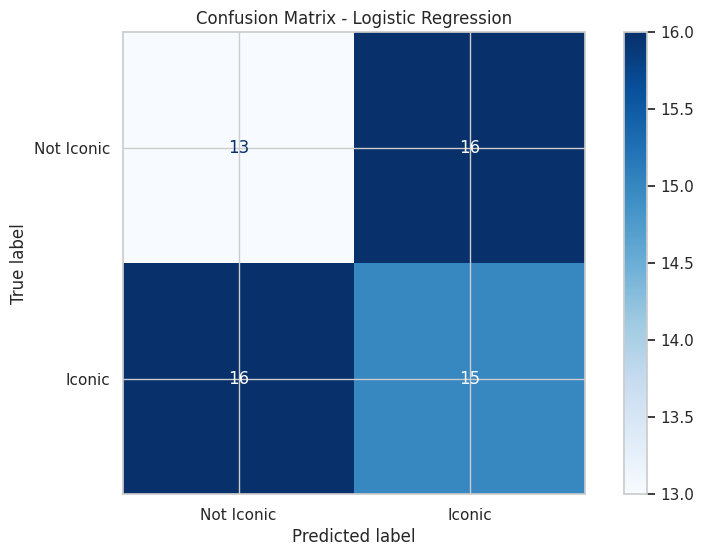

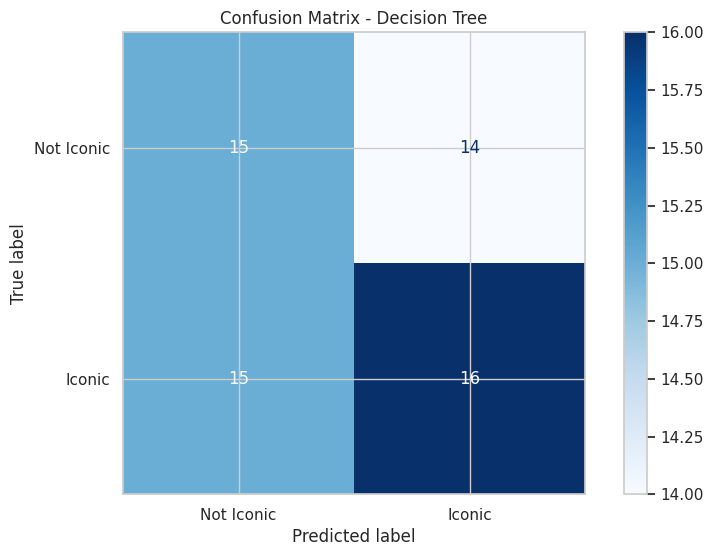

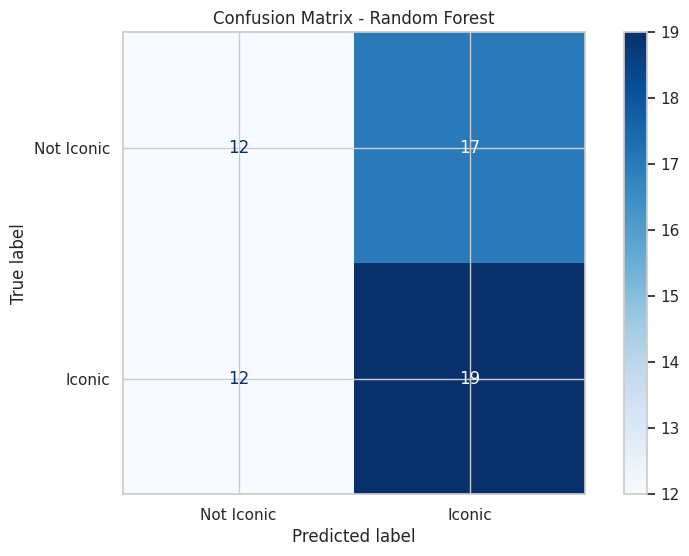

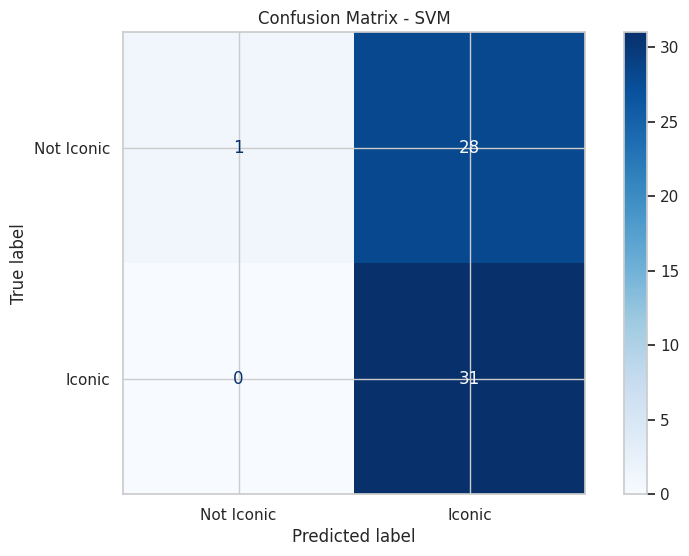

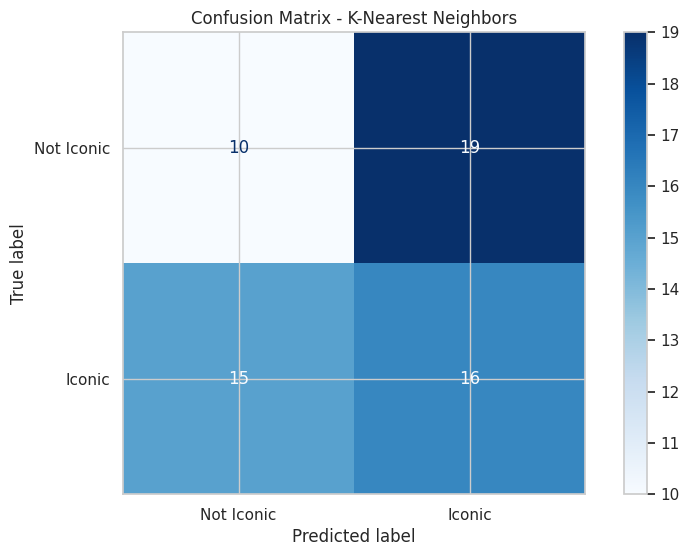

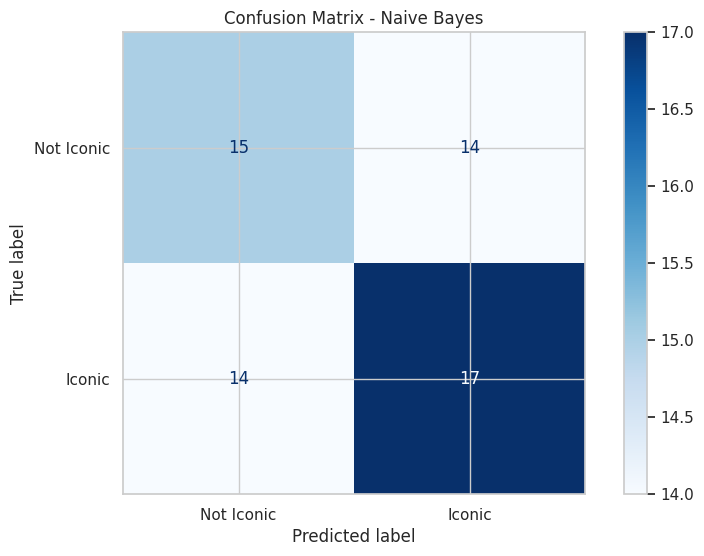


Model Accuracies (%):
Logistic Regression: 46.67%
Decision Tree: 51.67%
Random Forest: 51.67%
SVM: 53.33%
K-Nearest Neighbors: 43.33%
Naive Bayes: 53.33%


In [24]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = acc

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Iconic', 'Iconic'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Show accuracy results
print("\nModel Accuracies (%):")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")


## Thank you..pld upvote!!!